In [1]:
import numpy as np
from database import fetchGWMeanVarStd, fetchMeasGWT, fetchGST, fetchGeoProfile, fetchDarcyFlux
from solver import calcInterTemps, Solver, plotPredVSMeas

In [2]:
FIGW: int = 8 #general figure width

Select GWT point

In [3]:
GWTPoint = 6078

Fetch the needed data

In [4]:
GW_mean, GW_var, GW_std = fetchGWMeanVarStd(GWTPoint)
GEO_df = fetchGeoProfile(GWTPoint)
GST_df = fetchGST(GWTPoint, 'AreaType')
GWT_df = fetchMeasGWT(GWTPoint)
IC_df = GWT_df[GWT_df['YearMonth'] == GWT_df['YearMonth'].min()] #oldest GWT profile
q = fetchDarcyFlux(GWTPoint)

Create Solver

In [5]:
#Layer Parameters------------------------------------------------------------------
xm_0, xm_1 = GEO_df['Z0'].to_numpy(), GEO_df['Z1'].to_numpy() #layer start and end
lambm, Cm, km = GEO_df['Lamb'].to_numpy(), GEO_df['C'].to_numpy(), GEO_df['Lamb'].to_numpy(),  #conductivity, vol. heat capacity, interface/contact conductivity

#BC----------------------------------------------------------------------------------
surf_temps, surf_times = GST_df['GST'].to_numpy(), GST_df['t'].to_numpy() #top BC
alphaM1, alphaM2 = 1, lambm[-1] #bottom BC

#IC---------------------------------------------------------------------------------
interface_temps = calcInterTemps(IC_df['T'], IC_df['Z'], xm_1, surf_temps[0]) 

#Solver----------------------------------------------------------------------
slvr = Solver(xm_0, xm_1, q, lambm, Cm, km, surf_temps, surf_times, alphaM1, alphaM2, interface_temps)
slvr.nonDimensionalize()

RMSE of the fitted IC: 9.88e-01


Check solver IC and BC

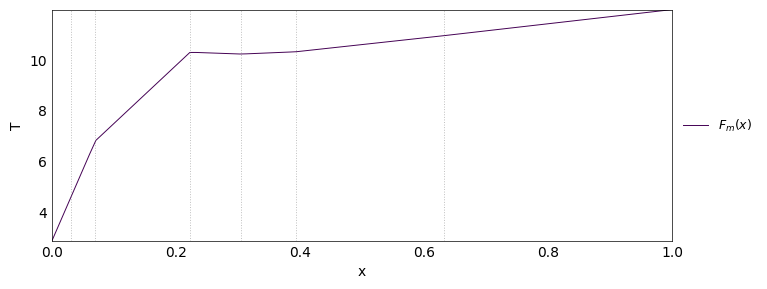

In [6]:
slvr.plotInitialConds(fig_width=FIGW)

Calculate steady state solution

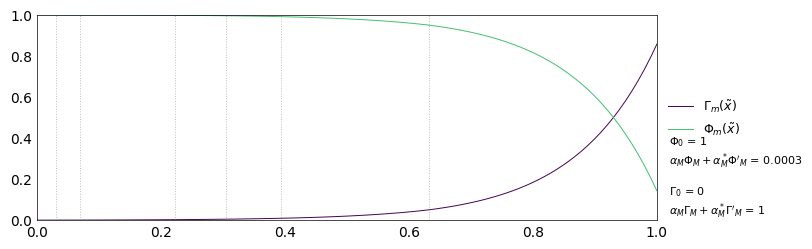

In [7]:
slvr.calcStdSolParams()
slvr.plotSteadySol(fig_width=FIGW)

Find eigenvalues

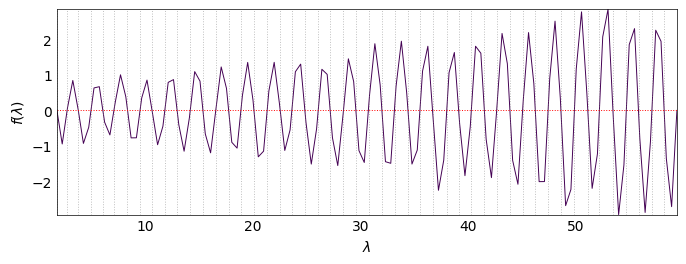

In [8]:
slvr.findEigenvalues(num_eigvals = 50, fig_width=FIGW)

Calculate transient solution components

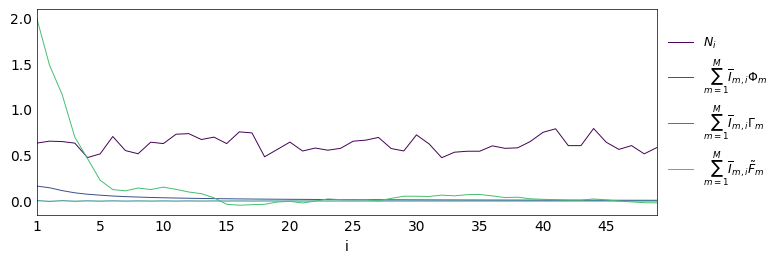

In [9]:
slvr.calcTransSolParams()
slvr.plotConvergence(fig_width=FIGW)

Check orthogonality

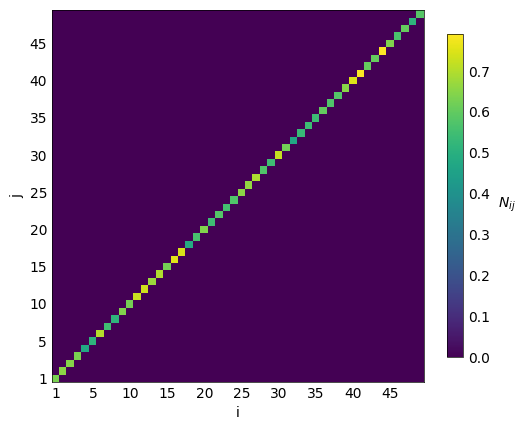

In [10]:
slvr.plotOrthogonality(print_results=False, fig_width=6)

Calculate final solution - comparison between measured and calculated

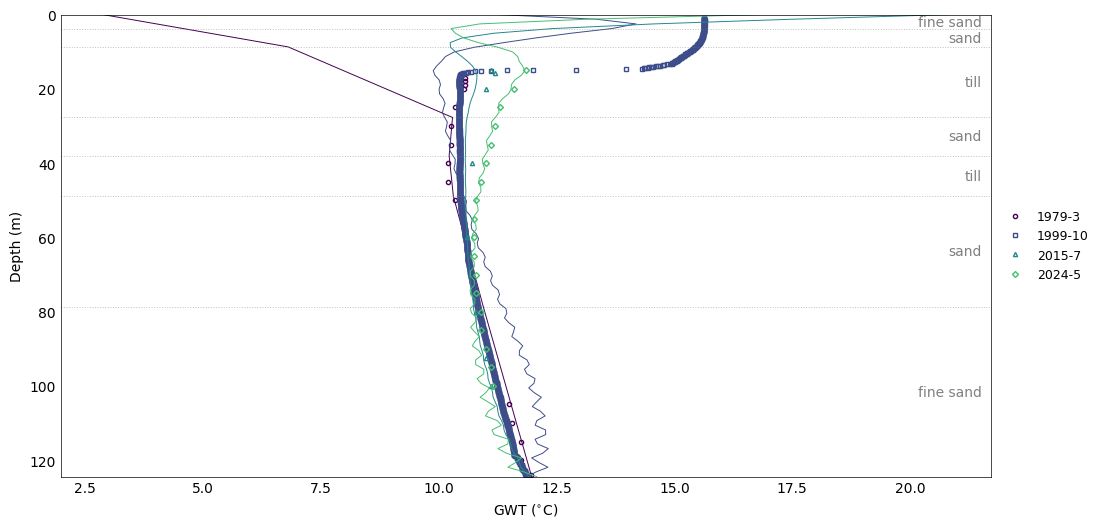

In [11]:
labels = GWT_df['YearMonth'].unique() #time stamps
soil_types = GEO_df['Soil'].to_numpy() #soil types / names

#measured data---------------------------------------------------------------------
T_measured = [GWT_df.loc[GWT_df['YearMonth'] == i, 'T'].to_numpy() for i in labels]
x_measured = [GWT_df.loc[GWT_df['YearMonth'] == i, 'Z'].to_numpy() for i in labels]

#solution params-------------------------------------------------------------------
N_res_points: int = 100 #number of points in x
x_array = np.linspace(xm_0[0], xm_1[-1], N_res_points)
t_array = GST_df.loc[GST_df['YearMonth'].isin(labels), 't'].to_numpy()

#nondimensionalize the solution params---------------------------------------------
nd_x_array = slvr.nonDim_x(x_array)
nd_t_array = slvr.nonDim_t(t_array)

#calculate the predicted values-----------------------------------------------------
T_predicted = slvr.calcFinalSol(nd_x_array, nd_t_array)
x_predicted = [x_array for i in range(t_array.shape[0])]

#plot the data
plotPredVSMeas(labels, x_predicted, T_predicted, x_measured, T_measured, interface_temps, xm_1, soil_types)